# 05. Advanced MCMC Techniques
This notebook covers advanced Markov Chain Monte Carlo methods and diagnostics.

## What You'll Learn

- Multiple chains and convergence diagnostics
- Comparing MCMC samplers (RWMH, ARWMH, DEMCz, DEMCzs, HMC)
- Effective sample size and autocorrelation
- Adaptive sampling strategies
- Handling multimodal posteriors
- Hierarchical models
- Sampler tuning and optimization

**Note:** Many code blocks in this notebook have long run times due to the computationally expensive methods we are testing. Please allow between 5-10 minutes of runtime per block before becoming concerned. 

## Set Up

In [ ]:
import pythonnet
pythonnet.load("coreclr")

import clr
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from System.Collections.Generic import List

# Load Numerics DLL
dll_path = Path(r"C:\GIT\Numerics\Numerics\bin\Debug\net8.0\Numerics.dll")
clr.AddReference(str(dll_path))

from Numerics.Distributions import Normal, Uniform, Weibull, IUnivariateDistribution
from Numerics.Sampling.MCMC import MCMCSampler, LogLikelihood, RWMH, ARWMH, DEMCz, DEMCzs, HMC, MCMCResults 
from Numerics.Mathematics.LinearAlgebra import Matrix
from helper_functions import convert_to_dotnet_array

print("✓ Setup complete")


✓ Setup complete


## Helper Functions
The basics of these functions are covered in previous notebooks. We define there here as helper functions to use in the rest of the notebook for efficiecy.

In [77]:
def extract_chain_samples(results, param_indx):
    """Extract parameter samples from MCMC sampler."""
    param_samples = []
    chains = []
    for c in range(len(results.MarkovChains)):
        chain_c = [results.MarkovChains[c][i].Values[param_indx]
                   for i in range(len(results.MarkovChains[c]))]
        chains.append(chain_c)
    return chains

def compute_rhat(chains):
    """Compute Gelman-Rubin R-hat convergence diagnostic."""
    n_chains = len(chains)
    n_samples = len(chains[0])
    
    # Within-chain variance
    W = np.mean([np.var(chain, ddof=1) for chain in chains])
    
    # Between-chain variance
    chain_means = [np.mean(chain) for chain in chains]
    B = n_samples * np.var(chain_means, ddof=1)
    
    # Estimated variance
    var_est = ((n_samples - 1) / n_samples) * W + (1 / n_samples) * B
    
    # R-hat
    rhat = np.sqrt(var_est / W)
    
    return rhat

def compute_ess(samples):
    """Compute Effective Sample Size."""
    n = len(samples)
    mean = np.mean(samples)
    variance = np.var(samples, ddof=1)
    
    # Compute autocorrelation
    max_lag = min(n // 2, 1000)
    autocorr = np.correlate(samples - mean, samples - mean, mode='full')
    autocorr = autocorr[n-1:n-1+max_lag] / (variance * n)
    
    # Sum until autocorrelation becomes negligible
    rho_sum = 0
    for lag in range(1, len(autocorr)):
        if autocorr[lag] < 0.05:  # Threshold
            break
        rho_sum += autocorr[lag]
    
    ess = n / (1 + 2 * rho_sum)
    return ess

def plot_trace(samples, param_names, title="Trace Plots"):
    """Plot MCMC trace plots."""
    n_params = len(samples)
    fig, axes = plt.subplots(n_params, 1, figsize=(12, 3*n_params))
    
    if n_params == 1:
        axes = [axes]
    
    for i, (sample, name) in enumerate(zip(samples, param_names)):
        axes[i].plot(sample, linewidth=0.5, alpha=0.7)
        axes[i].set_ylabel(name, fontsize=11)
        axes[i].set_xlabel('Iteration', fontsize=11)
        axes[i].grid(True, alpha=0.3)
        
        # Add mean line
        axes[i].axhline(np.mean(sample), color='red', linestyle='--', 
                       linewidth=2, label=f'Mean: {np.mean(sample):.3f}')
        axes[i].legend(fontsize=9)
    
    fig.suptitle(title, fontsize=14, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()

def plot_posterior(samples, param_names, true_values=None, title="Posterior Distributions"):
    """Plot posterior distributions."""
    colors = ['steelblue', 'steelblue', 'steelblue', 'steelblue']
    n_params = len(samples)
    fig, axes = plt.subplots(1, n_params, figsize=(5*n_params, 4))
    
    if n_params == 1:
        axes = [axes]
    
    for i, (sample, name) in enumerate(zip(samples, param_names)):
        axes[i].hist(sample, bins=50, density=True, alpha=0.7, 
                    color=colors)
        axes[i].set_xlabel(name, fontsize=12)
        axes[i].set_ylabel('Density', fontsize=12)
        axes[i].grid(True, alpha=0.3, axis='y')
        
        if true_values is not None:
            axes[i].axvline(true_values[i], color='red', linestyle='--', 
                          linewidth=2, label=f'True: {true_values[i]:.3f}')
            axes[i].legend(fontsize=10)
    
    fig.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

## Multiple Chins for Convergence Assessment
Running multiple chains helps diagnose convergence and assess mixing.

In [ ]:
# Generate synthetic data
np.random.seed(1234)
true_mu = 100
true_sigma = 15
data = np.random.normal(true_mu, true_sigma, 100)
data_net = convert_to_dotnet_array(data)

# Define priors
priors = List[IUnivariateDistribution]()
priors.Add(Uniform(50, 150))   # Prior for mu
priors.Add(Uniform(5, 30))     # Prior for sigma

# Log-likelihood function
def log_likelihood(params):
    dist = Normal(params[0], params[1])
    return sum(dist.LogPDF(x) for x in data)

# Convert to .NET Func
log_lik_func = LogLikelihood(log_likelihood)

# Run 4 independent chains 
n_chains = 4
chains_mu = []
chains_sigma = []

proposal = Matrix(2, 2)
proposal[0, 0] = 1.0   # variance for mu
proposal[1, 1] = 1.0   # variance for sigma
proposal[0, 1] = 0.0   # covariance
proposal[1, 0] = 0.0

sampler = RWMH(priors, log_lik_func, proposal)
sampler.Initalize = MCMCSampler.InitializationType.Randomize
sampler.NumberofChains = n_chains

sampler.Sample()

results = MCMCResults(sampler)

print("✓ Complete")

Available RWMH constructors:

Constructor 1:
  - priorDistributions: System.Collections.Generic.List`1[Numerics.Distributions.IUnivariateDistribution]
  - logLikelihoodFunction: Numerics.Sampling.MCMC.LogLikelihood
  - proposalSigma: Numerics.Mathematics.LinearAlgebra.Matrix
✓ Complete


## 2. Convergence Diagnostics: R-hat

R-hat (Gelman-Rubin statistic) compares within-chain and between-chain variance.

- **R-hat < 1.01**: Excellent convergence
- **R-hat < 1.05**: Good convergence
- **R-hat > 1.1**: Poor convergence, run longer

Convergence Diagnostics (R-hat):
μ:     1.0003  ✓ Converged
σ:     1.0003  ✓ Converged


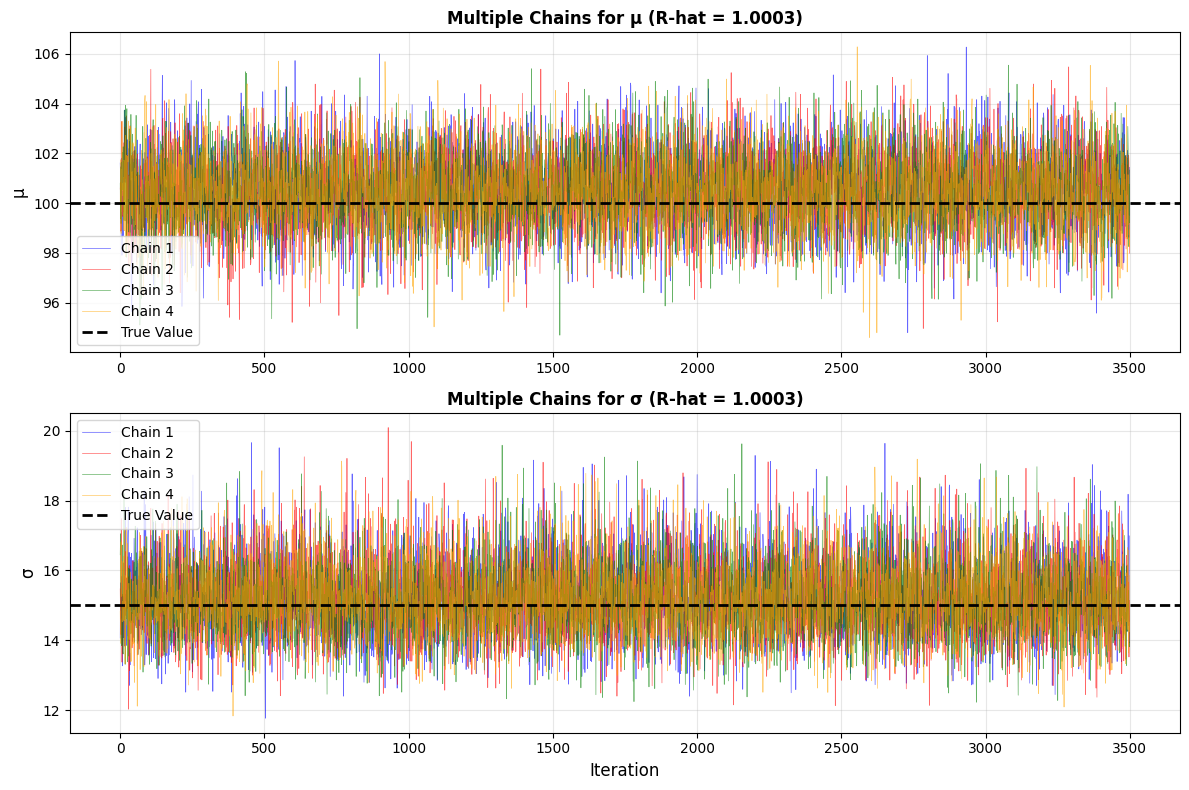

In [40]:
# Extract samples
chains_mu    = extract_chain_samples(results, 0)
chains_sigma = extract_chain_samples(results, 1)

# Compute R-hat for each parameter
rhat_mu = compute_rhat(chains_mu)
rhat_sigma = compute_rhat(chains_sigma)

print("Convergence Diagnostics (R-hat):")
print("=" * 50)
print(f"μ:     {rhat_mu:.4f}  {'✓ Converged' if rhat_mu < 1.05 else '✗ Not converged'}")
print(f"σ:     {rhat_sigma:.4f}  {'✓ Converged' if rhat_sigma < 1.05 else '✗ Not converged'}")

# Plot chains
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

colors = ['blue', 'red', 'green', 'orange']
for i, chain in enumerate(chains_mu):
    axes[0].plot(chain, alpha=0.6, linewidth=0.5, label=f'Chain {i+1}', color=colors[i])
axes[0].axhline(true_mu, color='black', linestyle='--', linewidth=2, label='True Value')
axes[0].set_ylabel('μ', fontsize=12)
axes[0].set_title(f'Multiple Chains for μ (R-hat = {rhat_mu:.4f})', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

for i, chain in enumerate(chains_sigma):
    axes[1].plot(chain, alpha=0.6, linewidth=0.5, label=f'Chain {i+1}', color=colors[i])
axes[1].axhline(true_sigma, color='black', linestyle='--', linewidth=2, label='True Value')
axes[1].set_xlabel('Iteration', fontsize=12)
axes[1].set_ylabel('σ', fontsize=12)
axes[1].set_title(f'Multiple Chains for σ (R-hat = {rhat_sigma:.4f})', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Effective Sample Size (ESS)

ESS accounts for autocorrelation in MCMC samples. Higher is better.

- **ESS > 1000**: Good for inference
- **ESS < 100**: May need longer chains


Effective Sample Size:
Total samples:  14000
ESS (μ):        11257  (80.4% efficiency)
ESS (σ):        14000  (100.0% efficiency)


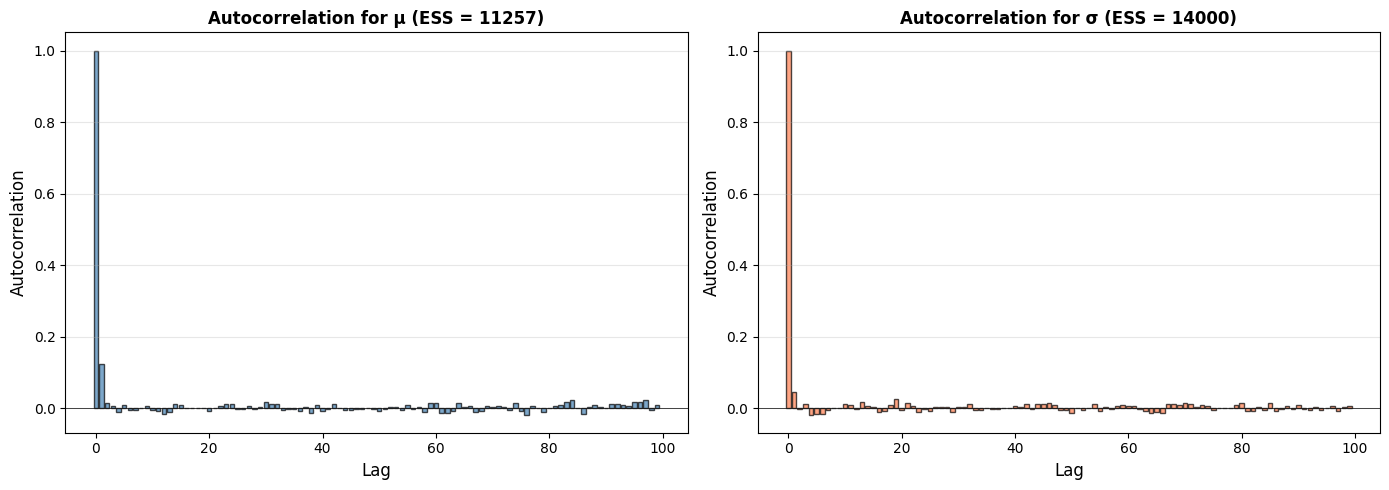

In [ ]:
# Combine all chains
combined_mu = np.concatenate(chains_mu)
combined_sigma = np.concatenate(chains_sigma)

# Compute ESS
ess_mu = compute_ess(combined_mu)
ess_sigma = compute_ess(combined_sigma)

print("\nEffective Sample Size:")
print("=" * 50)
print(f"Total samples:  {len(combined_mu)}")
print(f"ESS (μ):        {ess_mu:.0f}  ({ess_mu/len(combined_mu)*100:.1f}% efficiency)")
print(f"ESS (σ):        {ess_sigma:.0f}  ({ess_sigma/len(combined_sigma)*100:.1f}% efficiency)")

## COME BACK - USE NUMERICS AUTOCORRELATION
# Plot autocorrelation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

max_lag = 100
lags = range(max_lag)

# Autocorrelation for mu
autocorr_mu = np.correlate(combined_mu - np.mean(combined_mu), 
                           combined_mu - np.mean(combined_mu), mode='full')
autocorr_mu = autocorr_mu[len(combined_mu)-1:len(combined_mu)-1+max_lag] / autocorr_mu[len(combined_mu)-1]

axes[0].bar(lags, autocorr_mu, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].set_xlabel('Lag', fontsize=12)
axes[0].set_ylabel('Autocorrelation', fontsize=12)
axes[0].set_title(f'Autocorrelation for μ (ESS = {ess_mu:.0f})', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# Autocorrelation for sigma
autocorr_sigma = np.correlate(combined_sigma - np.mean(combined_sigma), 
                              combined_sigma - np.mean(combined_sigma), mode='full')
autocorr_sigma = autocorr_sigma[len(combined_sigma)-1:len(combined_sigma)-1+max_lag] / autocorr_sigma[len(combined_sigma)-1]

axes[1].bar(lags, autocorr_sigma, alpha=0.7, color='coral', edgecolor='black')
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_xlabel('Lag', fontsize=12)
axes[1].set_ylabel('Autocorrelation', fontsize=12)
axes[1].set_title(f'Autocorrelation for σ (ESS = {ess_sigma:.0f})', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 4. Adaptive Sampling (ARWMH)

ARWMH automatically tunes the proposal distribution during burn-in for optimal acceptance rates.

Target acceptance rate: ~23-44% for multivariate problems.

Adaptive RWMH Results:
μ estimate:  100.53 (true: 100)
σ estimate:  15.19 (true: 15)
ESS (μ): 14000
ESS (σ): 14000
Acceptance rate for chain 0: 0.37
Acceptance rate for chain 1: 0.38
Acceptance rate for chain 2: 0.37
Acceptance rate for chain 3: 0.37


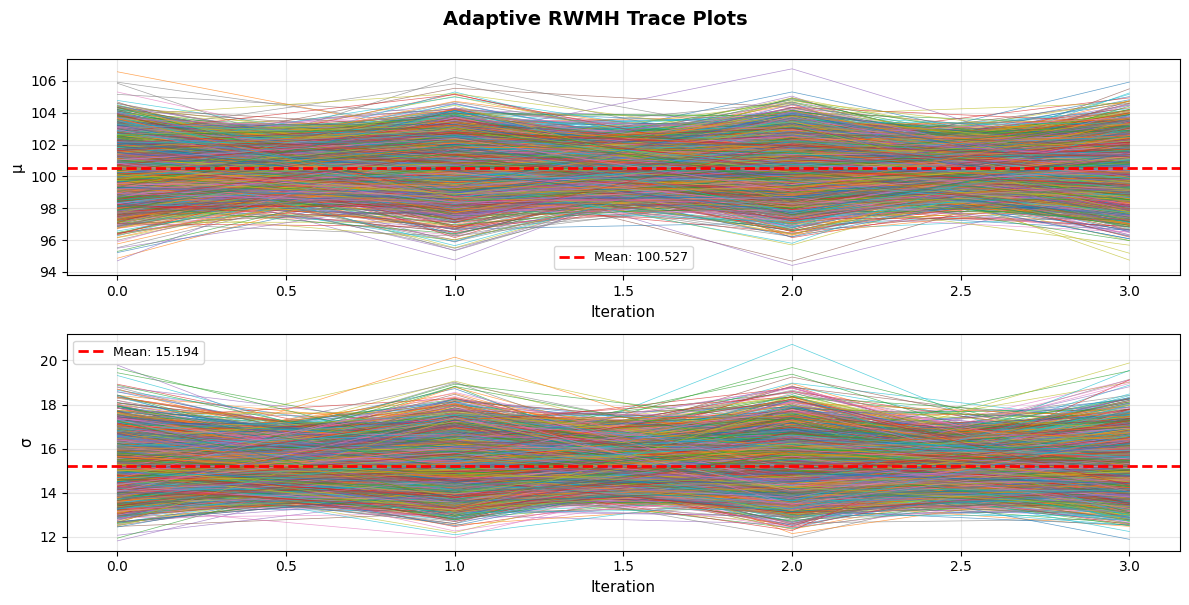

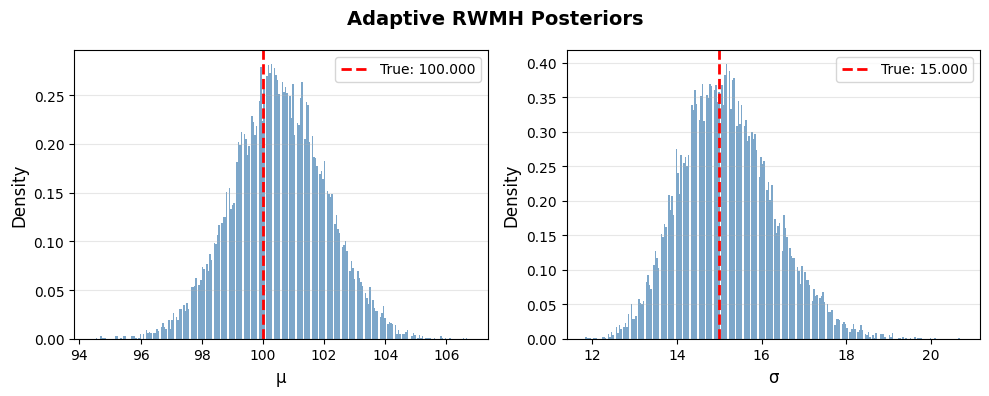

In [ ]:
# Create ARWMH sampler
arwmh = ARWMH(priors, log_lik_func)
arwmh.BurnIn = 2000  # Longer burn-in for adaptation
arwmh.SampleSize = 5000

# Sample
arwmh.Sample()

# Extract samples
mu_samples = extract_chain_samples(arwmh, 0)
sigma_samples = extract_chain_samples(arwmh, 1)

# For ESS
combined_mu = np.concatenate(mu_samples)
combined_sigma = np.concatenate(sigma_samples)

print("Adaptive RWMH Results:")
print("=" * 50)
print(f"μ estimate: {np.mean(mu_samples):.2f} (true: {true_mu})")
print(f"σ estimate: {np.mean(sigma_samples):.2f} (true: {true_sigma})")
print(f"ESS (μ): {compute_ess(combined_mu):.0f}")
print(f"ESS (σ): {compute_ess(combined_sigma):.0f}")
for i, accept in enumerate(arwmh.AcceptanceRates):
    print(f"Acceptance rate for chain {i}: {accept:.2f}")

# Plot results
plot_trace([mu_samples, sigma_samples], ['μ', 'σ'], title="Adaptive RWMH Trace Plots")
plot_posterior([mu_samples, sigma_samples], ['μ', 'σ'], [true_mu, true_sigma],
              title="Adaptive RWMH Posteriors")

## 5. Handling Multimodal Posteriors

Some posteriors have multiple peaks. DEMCz and DEMCzs are better at exploring these.

Fitting mixture model with DEMCz...

Mixture Model Estimates:
μ1:      106.19
σ1:      9.30
μ2:      99.07
σ2:      9.99
weight:  0.49


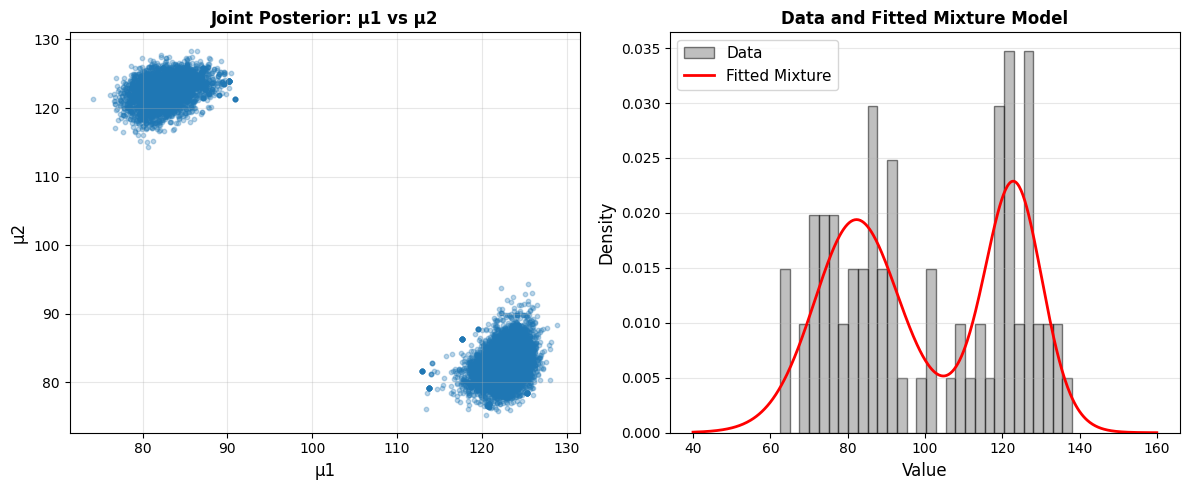

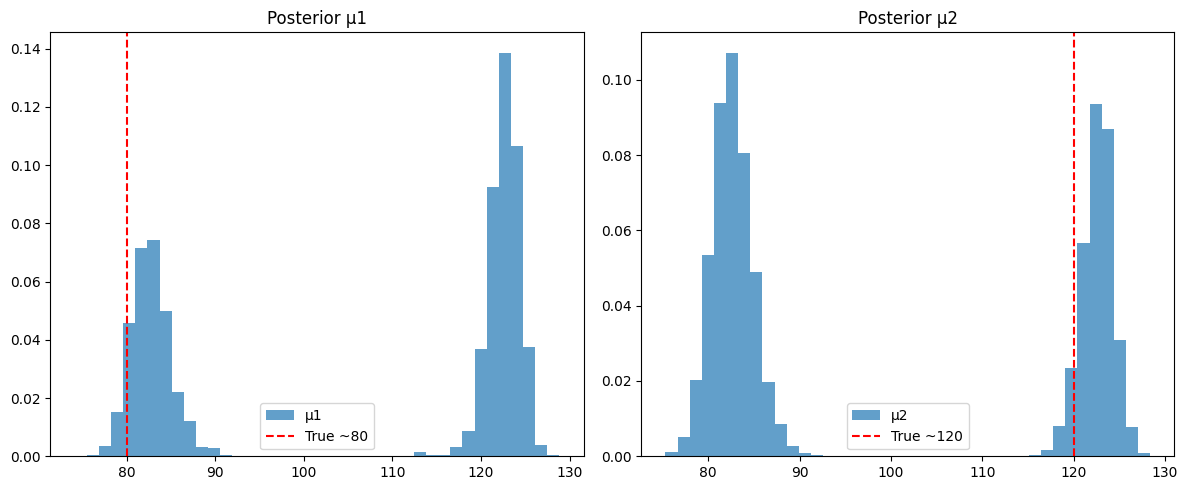

In [93]:
# Create bimodal mixture data
np.random.seed(789)
mode1 = np.random.normal(80, 10, 40)
mode2 = np.random.normal(120, 10, 40)
bimodal_data = np.concatenate([mode1, mode2])
bimodal_net = convert_to_dotnet_array(bimodal_data)

# Priors for mixture model
priors_mixture = List[IUnivariateDistribution]()
priors_mixture.Add(Uniform(50, 150))   # mu1
priors_mixture.Add(Uniform(5, 20))     # sigma1
priors_mixture.Add(Uniform(50, 150))   # mu2
priors_mixture.Add(Uniform(5, 20))     # sigma2
priors_mixture.Add(Uniform(0.01, 0.99))  # weight

# Mixture model log-likelihood
def log_lik_mixture(params):
    mu1, sigma1, mu2, sigma2, weight = params[0], params[1], params[2], params[3], params[4]
    
    dist1 = Normal(mu1, sigma1)
    dist2 = Normal(mu2, sigma2)
    
    total_ll = 0
    for x in bimodal_data:
        prob = weight * np.exp(dist1.LogPDF(x)) + (1 - weight) * np.exp(dist2.LogPDF(x))
        if prob > 0:
            total_ll += np.log(prob)
        else:
            total_ll += -1e10
    
    return total_ll

log_lik_mixture_func = LogLikelihood(log_lik_mixture)

# Use DEMCz for multimodal posterior
print("Fitting mixture model with DEMCz...")
demcz = DEMCz(priors_mixture, log_lik_mixture_func)
demcz.BurnIn = 3000
demcz.SampleSize = 10000

demcz.Sample()

results = MCMCResults(demcz)

mu1_chains = extract_chain_samples(results, 0)
sigma1_chains = extract_chain_samples(results, 1)
mu2_chains = extract_chain_samples(results, 2)
sigma2_chains = extract_chain_samples(results, 3)
weight_chains = extract_chain_samples(results, 4)

mu1_samples = np.concatenate(mu1_chains)
sigma1_samples = np.concatenate(sigma1_chains)
mu2_samples = np.concatenate(mu2_chains)
sigma2_samples = np.concatenate(sigma2_chains)
weight_samples = np.concatenate(weight_chains)

print("\nMixture Model Estimates:")
print("=" * 50)
print(f"μ1:      {np.mean(mu1_samples):.2f}")
print(f"σ1:      {np.mean(sigma1_samples):.2f}")
print(f"μ2:      {np.mean(mu2_samples):.2f}")
print(f"σ2:      {np.mean(sigma2_samples):.2f}")
print(f"weight:  {np.mean(weight_samples):.2f}")


# Joint posterior plot
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(mu1_samples, mu2_samples, alpha=0.3, s=10)
plt.xlabel('μ1', fontsize=12)
plt.ylabel('μ2', fontsize=12)
plt.title('Joint Posterior: μ1 vs μ2', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(bimodal_data, bins=30, density=True, alpha=0.5, color='gray', 
         edgecolor='black', label='Data')
x_range = np.linspace(40, 160, 500)
mean_weight = np.mean(weight_samples)


# Use a subset of posterior samples to approximate posterior predictive
idx = np.random.choice(len(mu1_samples), size=min(1000, len(mu1_samples)), replace=False)

pdf_mixture = []
for x in x_range:
    vals = []
    for j in idx:
        d1 = Normal(mu1_samples[j], sigma1_samples[j])
        d2 = Normal(mu2_samples[j], sigma2_samples[j])
        vals.append(weight_samples[j] * d1.PDF(x) + (1 - weight_samples[j]) * d2.PDF(x))
    pdf_mixture.append(np.mean(vals))

plt.plot(x_range, pdf_mixture, 'r-', linewidth=2, label='Fitted Mixture')
plt.xlabel('Value', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.title('Data and Fitted Mixture Model', fontsize=12, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Marginal posterior plots
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.hist(mu1_samples, bins=40, alpha=0.7, density=True, label='μ1')
plt.axvline(80, color='red', linestyle='--', label='True ~80')
plt.legend(); plt.title('Posterior μ1')

plt.subplot(1,2,2)
plt.hist(mu2_samples, bins=40, alpha=0.7, density=True, label='μ2')
plt.axvline(120, color='red', linestyle='--', label='True ~120')
plt.legend(); plt.title('Posterior μ2')

plt.tight_layout()
plt.show()


## 6. Comparing MCMC Samplers

Different samplers have different strengths. Let's compare:

- **RWMH**: Random Walk Metropolis-Hastings (basic)
- **ARWMH**: Adaptive Random Walk MH (auto-tuning)
- **DEMCz**: Differential Evolution MCMC (population-based)
- **DEMCzs**: DEMCz with snooker update (better for complex posteriors)
- **HMC**: Hamiltonian Monte Carlo (uses gradients)

### Weibull Distribution Example

Fit a Weibull distribution to reliability data using different samplers.

In [54]:
# Generate Weibull data (failure times)
np.random.seed(123)
true_lambda = 100
true_kappa = 2.5
failure_times = np.random.weibull(true_kappa, 50) * true_lambda #COME BACK AND USE NUMERICS WEIBULL

# Priors for Weibull parameters
priors_weibull = List[IUnivariateDistribution]()
priors_weibull.Add(Uniform(50, 200))   # lambda (scale)
priors_weibull.Add(Uniform(1, 5))      # kappa (shape)

# Log-likelihood for Weibull
def log_lik_weibull(params):
    dist = Weibull(params[0], params[1])
    return sum(dist.LogPDF(x) for x in failure_times)

log_lik_weibull_func = LogLikelihood(log_lik_weibull)

# Compare samplers
samplers_to_test = {
    'RWMH': lambda: RWMH(priors_weibull, log_lik_weibull_func, proposal),
    'ARWMH': lambda: ARWMH(priors_weibull, log_lik_weibull_func),
    'DEMCz': lambda: DEMCz(priors_weibull, log_lik_weibull_func),
    'DEMCzs': lambda: DEMCzs(priors_weibull, log_lik_weibull_func),
    # 'HMC': lambda: HMC(priors_weibull, log_lik_weibull_func), # Takes one million years to run
}

out_results = {}
print("Comparing MCMC samplers...\n")

for name, create_sampler in samplers_to_test.items():
    print(f"Running {name}...")
    
    sampler = create_sampler()
    sampler.BurnIn = 1000
    sampler.SampleSize = 5000
    
    import time
    start = time.time()
    sampler.Sample()
    elapsed = time.time() - start

    results = MCMCResults(sampler)
    
    # Extract samples
    chains_lambda    = extract_chain_samples(results, 0)
    chains_kappa = extract_chain_samples(results, 1)

    # For ESS
    combined_lambda = np.concatenate(chains_lambda)
    combined_kappa = np.concatenate(chains_kappa)

    out_results[name] = {
        'lambda': chains_lambda,
        'kappa': chains_kappa,
        'time': elapsed,
        'ess_lambda': compute_ess(combined_lambda) if combined_lambda.size > 0 else 0,
        'ess_kappa': compute_ess(combined_kappa) if combined_kappa.size > 0 else 0
    }
    
    print(f"  Time: {elapsed:.2f}s")
    print(f"  λ estimate: {np.mean(chains_lambda):.2f} (true: {true_lambda})")
    print(f"  κ estimate: {np.mean(chains_kappa):.2f} (true: {true_kappa})")
    print(f"  ESS (λ): {out_results[name]['ess_lambda']:.0f}")
    print(f"  ESS (κ): {out_results[name]['ess_kappa']:.0f}\n")

Comparing MCMC samplers...

Running RWMH...
  Time: 153.77s
  λ estimate: 99.96 (true: 100)
  κ estimate: 3.04 (true: 2.5)
  ESS (λ): 957
  ESS (κ): 7528

Running ARWMH...
  Time: 167.90s
  λ estimate: 100.04 (true: 100)
  κ estimate: 3.05 (true: 2.5)
  ESS (λ): 14000
  ESS (κ): 14000

Running DEMCz...
  Time: 165.70s
  λ estimate: 99.97 (true: 100)
  κ estimate: 3.05 (true: 2.5)
  ESS (λ): 14000
  ESS (κ): 14000

Running DEMCzs...
  Time: 156.69s
  λ estimate: 99.98 (true: 100)
  κ estimate: 3.05 (true: 2.5)
  ESS (λ): 14000
  ESS (κ): 14000



Sampler Comparison:
Sampler   Time (s)     λ Mean    λ Std   κ Mean    κ Std      ESS (λ)      ESS (κ)
   RWMH 153.765225  99.962149 4.917850 3.042256 0.312016   957.397226  7528.151758
  ARWMH 167.903589 100.037132 5.016038 3.045251 0.312043 14000.000000 14000.000000
  DEMCz 165.702167  99.969226 5.026569 3.048010 0.314716 14000.000000 14000.000000
 DEMCzs 156.691463  99.982013 5.025966 3.045396 0.312354 14000.000000 14000.000000

True values: λ = 100, κ = 2.5


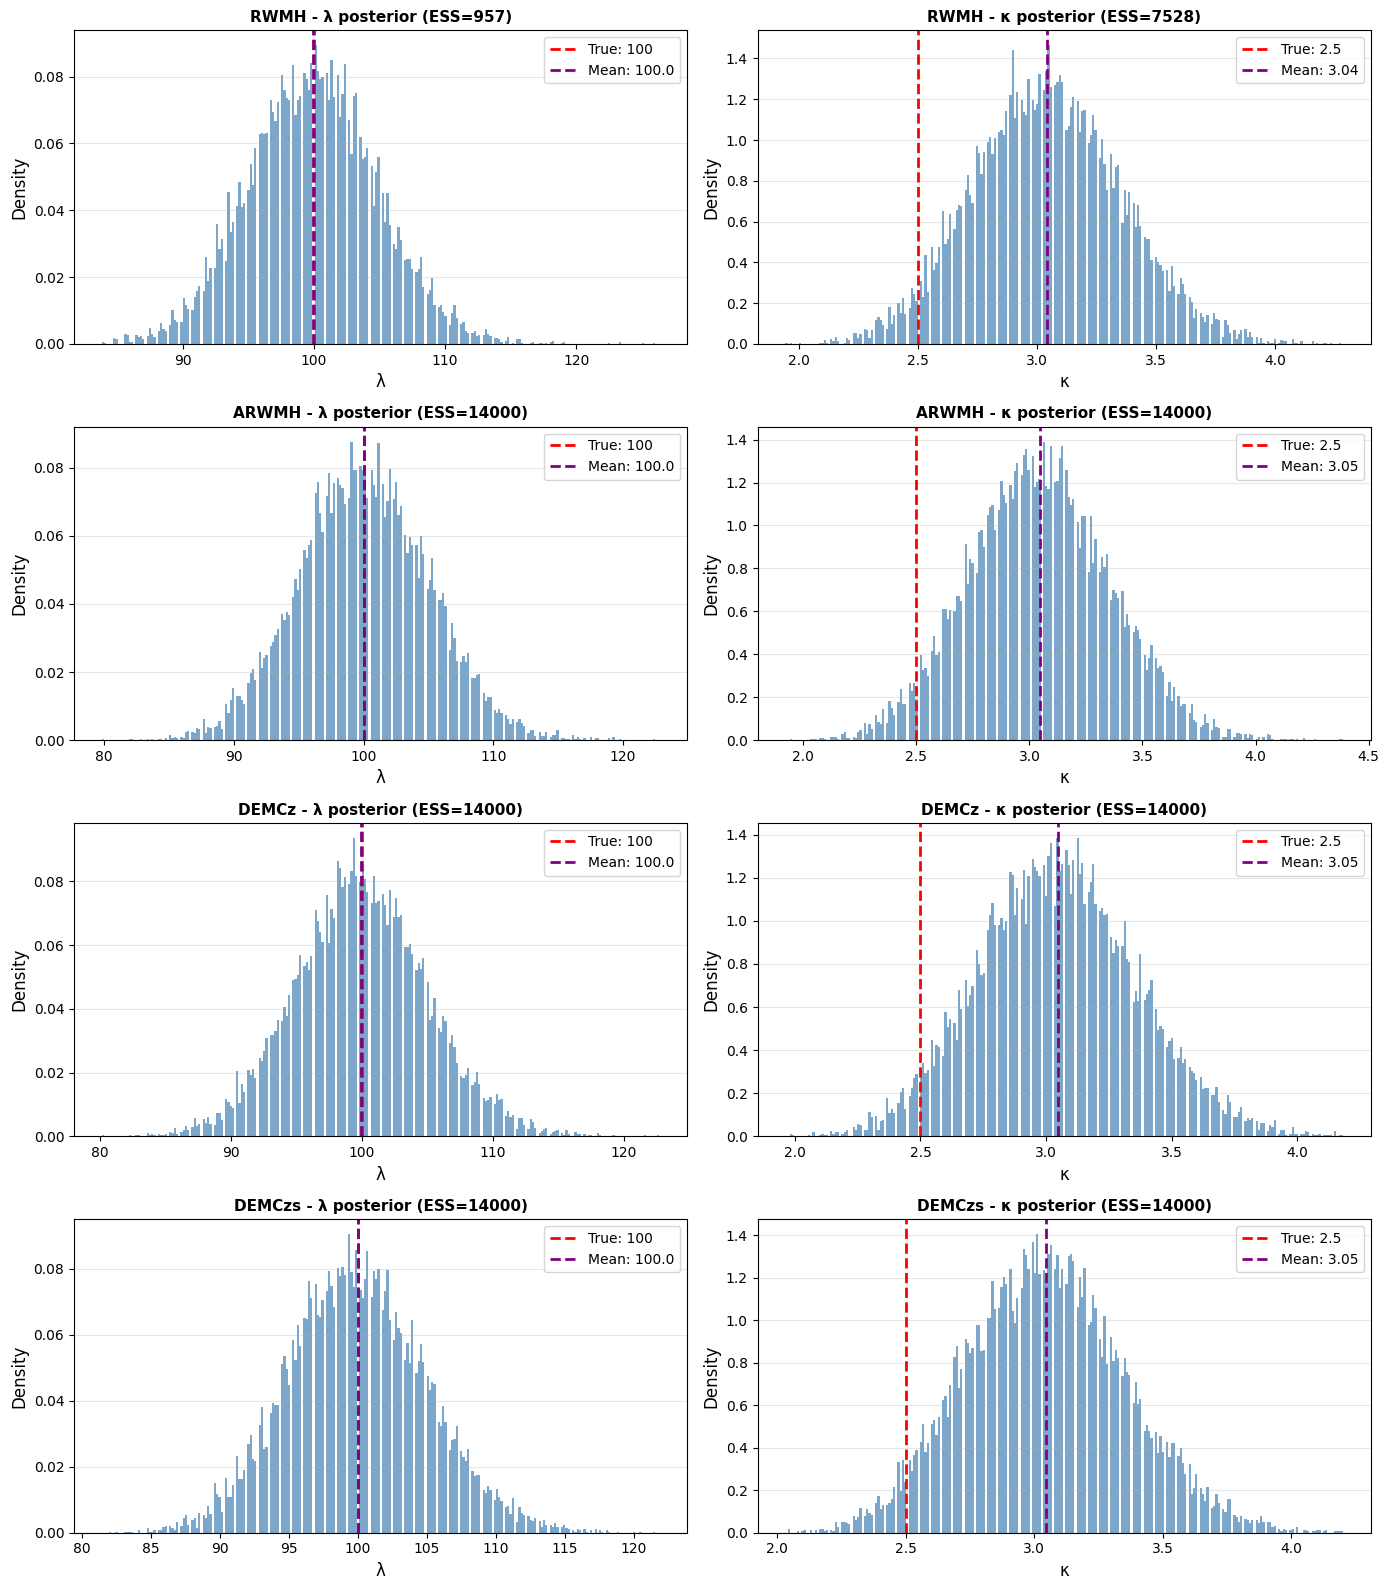

In [67]:
# Create comparison table
comparison_df = pd.DataFrame({
    'Sampler': list(out_results.keys()),
    'Time (s)': [out_results[s]['time'] for s in out_results],
    'λ Mean': [np.mean(out_results[s]['lambda']) for s in out_results],
    'λ Std': [np.std(out_results[s]['lambda']) for s in out_results],
    'κ Mean': [np.mean(out_results[s]['kappa']) for s in out_results],
    'κ Std': [np.std(out_results[s]['kappa']) for s in out_results],
    'ESS (λ)': [out_results[s]['ess_lambda'] for s in out_results],
    'ESS (κ)': [out_results[s]['ess_kappa'] for s in out_results]
})

print("Sampler Comparison:")
print("=" * 80)
print(comparison_df.to_string(index=False))
print(f"\nTrue values: λ = {true_lambda}, κ = {true_kappa}")

# Plot comparison
fig, axes = plt.subplots(len(out_results), 2, figsize=(14, 4*len(out_results)))

colors = ['steelblue', 'steelblue', 'steelblue', 'steelblue']

for i, (name, res) in enumerate(out_results.items()):
    # Lambda
    axes[i, 0].hist(res['lambda'], bins=50, density=True, alpha=0.7, 
                    color=colors)
    axes[i, 0].axvline(true_lambda, color='red', linestyle='--', linewidth=2, 
                       label=f'True: {true_lambda}')
    axes[i, 0].axvline(np.mean(res['lambda']), color='purple', linestyle='--', 
                       linewidth=2, label=f'Mean: {np.mean(res["lambda"]):.1f}')
    axes[i, 0].set_xlabel('λ', fontsize=12)
    axes[i, 0].set_ylabel('Density', fontsize=12)
    axes[i, 0].set_title(f'{name} - λ posterior (ESS={res["ess_lambda"]:.0f})', 
                        fontsize=11, fontweight='bold')
    axes[i, 0].legend(fontsize=10)
    axes[i, 0].grid(True, alpha=0.3, axis='y')
    
    # Kappa
    axes[i, 1].hist(res['kappa'], bins=50, density=True, alpha=0.7, 
                    color=colors)
    axes[i, 1].axvline(true_kappa, color='red', linestyle='--', linewidth=2, 
                       label=f'True: {true_kappa}')
    axes[i, 1].axvline(np.mean(res['kappa']), color='purple', linestyle='--', 
                       linewidth=2, label=f'Mean: {np.mean(res["kappa"]):.2f}')
    axes[i, 1].set_xlabel('κ', fontsize=12)
    axes[i, 1].set_ylabel('Density', fontsize=12)
    axes[i, 1].set_title(f'{name} - κ posterior (ESS={res["ess_kappa"]:.0f})', 
                        fontsize=11, fontweight='bold')
    axes[i, 1].legend(fontsize=10)
    axes[i, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 7. Tuning Tips and Best Practices

### General Guidelines

1. **Burn-in**: Use 10-50% of total iterations
2. **Sample size**: At least 1000 effective samples
3. **Multiple chains**: Run 3-4 chains to assess convergence
4. **Thinning**: Usually not necessary with modern samplers

### Sampler Selection

- **Simple problems**: RWMH or ARWMH
- **High dimensions**: DEMCz, DEMCzs
- **Multimodal**: DEMCzs
- **Smooth gradients available**: HMC
- **Computational budget limited**: ARWMH

### Troubleshooting

- **Low acceptance rate (<10%)**: Proposal too wide
- **High acceptance rate (>80%)**: Proposal too narrow
- **High autocorrelation**: Increase samples or use different sampler
- **R-hat > 1.1**: Run longer or check for bugs

## Summary

You've learned:
- Running multiple chains for convergence diagnostics
- Computing R-hat and ESS
- Comparing different MCMC samplers
- Adaptive sampling with ARWMH
- Handling multimodal posteriors with DEMCz
- Best practices for MCMC

## Key Takeaways

1. **Always check convergence** - Use R-hat and visual inspection
2. **ESS matters more than raw samples** - Account for autocorrelation
3. **Different samplers for different problems** - No one-size-fits-all
4. **Adaptive methods reduce tuning burden** - ARWMH, DEMCz are robust
5. **Multiple chains catch problems early** - Run at least 3-4 chains

## Next Steps

- **06_optimization.ipynb** - Optimization algorithms
- **04_mcmc_bayesian_inference.ipynb** - Real-world Bayesian modeling

## Exercise

1. Generate data from a Gamma distribution
2. Fit using 3 different MCMC samplers
3. Compare ESS and convergence
4. Which sampler performs best?